ARIMA
MAE : 0.666
RMSE: 0.98
---------------------
Random Forest
MAE : 0.621
RMSE: 0.824
---------------------


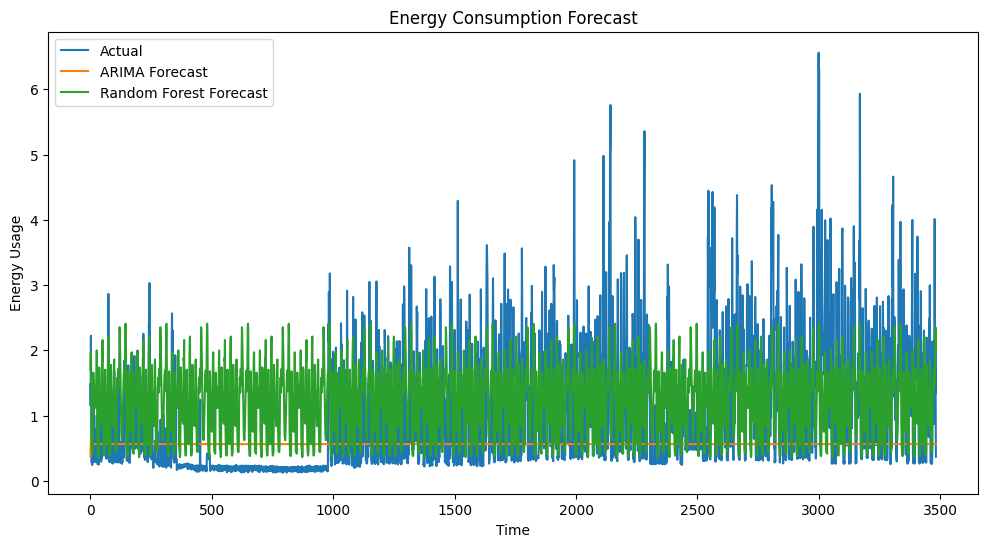

In [1]:
# =====================================
# Energy Consumption Time Series Model
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")


# ---------------------------
# 1. Load Dataset
# ---------------------------
df = pd.read_csv("household_power_consumption.csv")

# Create datetime column
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], errors="coerce")

# Select needed columns
df = df[["Datetime","Global_active_power"]]

# Convert to numeric
df["Global_active_power"] = pd.to_numeric(df["Global_active_power"], errors="coerce")

# Remove missing values
df.dropna(inplace=True)

# Set datetime index
df.set_index("Datetime", inplace=True)


# ---------------------------
# 2. Resample Hourly
# ---------------------------
df_hourly = df.resample("H").mean()

# Remove NaN after resampling
df_hourly.dropna(inplace=True)


# ---------------------------
# 3. Feature Engineering
# ---------------------------
df_hourly["hour"] = df_hourly.index.hour
df_hourly["dayofweek"] = df_hourly.index.dayofweek
df_hourly["is_weekend"] = (df_hourly["dayofweek"] >= 5).astype(int)


# ---------------------------
# 4. Train Test Split
# ---------------------------
train_size = int(len(df_hourly) * 0.8)

train = df_hourly[:train_size]
test = df_hourly[train_size:]

y_train = train["Global_active_power"]
y_test = test["Global_active_power"]


# ---------------------------
# 5. ARIMA Model
# ---------------------------
arima = ARIMA(y_train, order=(5,1,0))
arima_model = arima.fit()

arima_pred = arima_model.forecast(steps=len(test))


# ---------------------------
# 6. Random Forest Model
# ---------------------------
features = ["hour","dayofweek","is_weekend"]

X_train = train[features]
X_test = test[features]

rf = RandomForestRegressor(n_estimators=100)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)


# ---------------------------
# 7. Evaluation
# ---------------------------
def evaluate(actual,pred,name):
    
    mae = mean_absolute_error(actual,pred)
    rmse = np.sqrt(mean_squared_error(actual,pred))
    
    print(name)
    print("MAE :", round(mae,3))
    print("RMSE:", round(rmse,3))
    print("---------------------")

evaluate(y_test, arima_pred, "ARIMA")
evaluate(y_test, rf_pred, "Random Forest")


# ---------------------------
# 8. Visualization
# ---------------------------
plt.figure(figsize=(12,6))

plt.plot(y_test.values,label="Actual")
plt.plot(arima_pred.values,label="ARIMA Forecast")
plt.plot(rf_pred,label="Random Forest Forecast")

plt.title("Energy Consumption Forecast")
plt.xlabel("Time")
plt.ylabel("Energy Usage")

plt.legend()
plt.show()